# Project 4 — NLP & Sentiment Analysis
### DecodeLabs Data Science Industrial Training Kit — Batch 2026

**Goal:** Program a machine to read and mathematically categorize unstructured
human text (product reviews) as *Positive* or *Negative*.

This notebook implements the full pipeline required by the brief:

1. **Text Pre-Processing** — Tokenization, negation-safe Stop-Word removal, POS-guided Lemmatization
2. **Vectorization** — TF-IDF with unigrams + bigrams, bounded dimensionality
3. **Memory Optimization** — SciPy CSR sparse storage throughout
4. **Inference** — Multinomial / Complement Naive Bayes (Laplace smoothing) and a Linear SVM
5. **Evaluation** — accuracy, classification report, confusion matrix, and honest limitation testing

**Note on data:** no dataset was assigned in the brief, so Section 1 generates a
synthetic but realistically *noisy* product-review dataset (HTML break tags,
ALL-CAPS emphasis, stray punctuation, negation phrases) — the exact kind of
mess the brief's "80% Problem" and "Stop-Word Trap" slides describe.


## 0. Setup

In [1]:
import re
import time
import warnings
warnings.filterwarnings("ignore")

import nltk
import numpy as np
import pandas as pd
from scipy import sparse

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup complete.")


Setup complete.


## 1. Dataset — synthetic product reviews

600 reviews (balanced 300 positive / 300 negative) built from templates across
18 product categories, with realistic noise injected: `<br>` tags, `!!!`,
ALL-CAPS emphasis words, and negation phrasing ("not good", "isn't bad") —
so the pre-processing pipeline has real cleaning work to do.


In [2]:
import random
random.seed(RANDOM_STATE)

PRODUCTS = ["phone", "laptop", "blender", "headphones", "backpack", "watch",
            "camera", "speaker", "mattress", "shoes", "jacket", "monitor",
            "keyboard", "vacuum", "toaster", "charger", "tablet", "router"]

POSITIVE_ADJ = ["amazing", "excellent", "fantastic", "great", "wonderful",
                "superb", "outstanding", "reliable", "sturdy", "comfortable", "impressive"]
NEGATIVE_ADJ = ["terrible", "awful", "horrible", "disappointing", "flimsy",
                "useless", "poor", "cheap", "unreliable", "frustrating"]

POS_TEMPLATES = [
    "This {p} is {adj}!!! Exactly what I needed <br>",
    "I am really happy with this {p}, {adj} quality for the price.",
    "The {p} works great and the build quality is {adj}.",
    "Not bad at all -- actually a very {adj} {p}.",
    "Highly recommend this {p}, it is {adj} and arrived early. <br>",
    "Best {p} I've owned. {adj} in every way!",
    "I'm not disappointed one bit, this {p} is {adj}.",
    "Great {p}!! {adj} performance and easy to use. <br><br>",
    "The {p} exceeded my expectations, truly {adj}.",
    "So far so good -- {adj} {p}, will buy again.",
]
NEG_TEMPLATES = [
    "This {p} is {adj}!!! Total waste of money <br>",
    "I am not happy with this {p}, {adj} quality for the price.",
    "The {p} broke after a week, build quality is {adj}.",
    "Not good at all -- honestly a very {adj} {p}.",
    "Would not recommend this {p}, it is {adj} and arrived late. <br>",
    "Worst {p} I've owned. {adj} in every way!",
    "I'm not satisfied at all, this {p} is {adj}.",
    "Terrible {p}!! {adj} performance and hard to use. <br><br>",
    "The {p} fell short of my expectations, truly {adj}.",
    "So far so bad -- {adj} {p}, will not buy again.",
]
NEUTRAL_NEGATION_POS = ["This {p} isn't bad at all, actually quite {adj}.",
                         "Not what I expected -- turned out to be {adj}!"]
NEUTRAL_NEGATION_NEG = ["This {p} isn't great, honestly kind of {adj}.",
                         "Not the {adj} experience I was hoping for."]

def shout(word):
    return word.upper() if random.random() < 0.25 else word

def build_row(label):
    p = random.choice(PRODUCTS)
    if label == "positive":
        adj = random.choice(POSITIVE_ADJ)
        pool = NEUTRAL_NEGATION_POS if random.random() < 0.15 else POS_TEMPLATES
    else:
        adj = random.choice(NEGATIVE_ADJ)
        pool = NEUTRAL_NEGATION_NEG if random.random() < 0.15 else NEG_TEMPLATES
    text = random.choice(pool).format(p=p, adj=shout(adj))
    if random.random() < 0.2:
        text += random.choice([" ...", " :)", " :(", " ***", " ?!"])
    return text, label

rows = [build_row("positive") for _ in range(300)] + [build_row("negative") for _ in range(300)]
df = pd.DataFrame(rows, columns=["review", "sentiment"]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(df.shape)
print(df["sentiment"].value_counts())
df.head(8)


(600, 2)
sentiment
positive    300
negative    300
Name: count, dtype: int64


,review,sentiment
0,"This camera isn't bad at all, actually quite S...",positive
1,"The toaster broke after a week, build quality ...",negative
2,"The watch fell short of my expectations, truly...",negative
3,Not what I expected -- turned out to be reliable!,positive
4,Not bad at all -- actually a very FANTASTIC sp...,positive
5,The router works great and the build quality i...,positive
6,"The blender exceeded my expectations, truly co...",positive
7,Not good at all -- honestly a very cheap speaker.,negative


## 2. The Stop-Word Trap

Default NLP stop-word dictionaries include negations (`not`, `no`, `n't`, ...).
Removing them silently flips meaning:

| Step | Text | Outcome |
|---|---|---|
| Input | "I am not happy." | — |
| Default NLTK filter | "I am happy." | Predicts **POSITIVE** (wrong) |
| Negation-safe filter | "not happy." | Predicts **NEGATIVE** (correct) |

**Rule:** explicitly exclude negations from the stop-word set via a set
difference, rather than using the default list as-is.


In [3]:
NEGATIONS = {
    "no", "not", "nor", "none", "never", "n't",
    "don", "doesn", "didn", "isn", "aren", "wasn", "weren",
    "hasn", "haven", "hadn", "won", "wouldn", "shan", "shouldn",
    "can", "couldn", "mustn", "needn",
}

default_stopwords = set(stopwords.words("english"))
STOP_WORDS = default_stopwords - NEGATIONS

print(f"Default NLTK stopword count : {len(default_stopwords)}")
print(f"Negation-safe stopword count: {len(STOP_WORDS)}")
print(f"Negations preserved         : {sorted(default_stopwords & NEGATIONS)}")


Default NLTK stopword count : 198
Negation-safe stopword count: 177
Negations preserved         : ['aren', 'can', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'mustn', 'needn', 'no', 'nor', 'not', 'shan', 'shouldn', 'wasn', 'weren', 'won', 'wouldn']


## 3. Text Pre-Processing Pipeline

Character normalization → tokenization → POS tagging → negation-safe
stop-word removal → **POS-guided** lemmatization (`WordNetLemmatizer`).

POS-guidance matters: without a POS tag, `went` lemmatizes to `went` (assumed
noun); with the verb tag it correctly reduces to `go`. We map Penn Treebank
tags (from `nltk.pos_tag`) to the WordNet tag set the lemmatizer expects.


In [4]:
lemmatizer = WordNetLemmatizer()

TREEBANK_TO_WORDNET = {"J": "a", "V": "v", "N": "n", "R": "r"}

def wordnet_pos(treebank_tag):
    return TREEBANK_TO_WORDNET.get(treebank_tag[0], "n")

def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def preprocess(text):
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tagged = nltk.pos_tag(tokens)
    out = []
    for word, tag in tagged:
        if word in STOP_WORDS:
            continue
        if len(word) <= 1 and word not in NEGATIONS:
            continue
        out.append(lemmatizer.lemmatize(word, pos=wordnet_pos(tag)))
    return " ".join(out)

# demo straight from the brief's own example
demo = "This product is TERRIBLE!!! <br> I am not happy, it isn't good."
print("raw       :", demo)
print("cleaned   :", clean_text(demo))
print("processed :", preprocess(demo))

# POS-guided lemmatization proof: "went" -> "go" only with the verb tag
print()
print("lemmatize('went')          :", lemmatizer.lemmatize("went"))
print("lemmatize('went', pos='v') :", lemmatizer.lemmatize("went", pos="v"))


raw       : This product is TERRIBLE!!! <br> I am not happy, it isn't good.
cleaned   : this product is terrible i am not happy it isn't good


processed : product terrible not happy n't good

lemmatize('went')          : went
lemmatize('went', pos='v') : go


In [5]:
t0 = time.time()
df["clean"] = df["review"].apply(preprocess)
print(f"Pre-processed {len(df)} reviews in {time.time() - t0:.2f}s")
df[["review", "clean", "sentiment"]].head(8)


Pre-processed 600 reviews in 0.14s


,review,clean,sentiment
0,"This camera isn't bad at all, actually quite S...",camera n't bad actually quite superb,positive
1,"The toaster broke after a week, build quality ...",toaster break week build quality frustrate,negative
2,"The watch fell short of my expectations, truly...",watch fell short expectation truly awful,negative
3,Not what I expected -- turned out to be reliable!,not expect turn reliable,positive
4,Not bad at all -- actually a very FANTASTIC sp...,not bad actually fantastic speaker,positive
5,The router works great and the build quality i...,router work great build quality impressive,positive
6,"The blender exceeded my expectations, truly co...",blender exceed expectation truly comfortable,positive
7,Not good at all -- honestly a very cheap speaker.,not good honestly cheap speaker,negative


## 4. TF-IDF Vectorization

Converts cleaned tokens into numeric vectors. `TF` (how often a word appears
in *this* document) is multiplied by `IDF` (how rare it is *across* all
documents) — common words like "the" get weighted toward ~0, distinctive
words like "terrible" get weighted high.

We use **unigrams + bigrams** (`ngram_range=(1,2)`) to capture two-word
phrases like `"not good"` that a single-word model would miss — bounded by
`max_features` and `min_df=2` to stop the vocabulary (and therefore the
matrix) from exploding, per the brief's "Memory Crash" warning.


In [6]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=2)
X = vectorizer.fit_transform(df["clean"])
y = (df["sentiment"] == "positive").astype(int).values

print(f"TF-IDF matrix shape : {X.shape}")
print(f"Matrix type          : {type(X)}")
print(f"Non-zero entries      : {X.nnz:,} / {X.shape[0] * X.shape[1]:,} cells")
print(f"Sparsity              : {100 * (1 - X.nnz / (X.shape[0] * X.shape[1])):.2f}% zeros")

sample_bigrams = [f for f in vectorizer.get_feature_names_out() if " " in f][:10]
print("\nExample bigram features learned:", sample_bigrams)


TF-IDF matrix shape : (600, 525)
Matrix type          : <class 'scipy.sparse._csr.csr_matrix'>
Non-zero entries      : 5,657 / 315,000 cells
Sparsity              : 98.20% zeros

Example bigram features learned: ['actually amazing', 'actually fantastic', 'actually great', 'actually impressive', 'actually quite', 'actually reliable', 'actually sturdy', 'actually superb', 'amazing arrive', 'amazing every']


## 5. Memory Optimization — SciPy CSR Sparse Format

A 99%+ empty dense matrix wastes gigabytes of RAM. CSR (Compressed Sparse
Row) stores only the non-zero values plus their column indices and row
pointers — the industry standard for training linear classifiers on text.


In [7]:
X_csr = sparse.csr_matrix(X)
assert isinstance(X_csr, sparse.csr_matrix)

dense_bytes = X_csr.shape[0] * X_csr.shape[1] * 8
sparse_bytes = X_csr.data.nbytes + X_csr.indices.nbytes + X_csr.indptr.nbytes

print(f"Confirmed format : {type(X_csr).__name__}")
print(f"Would-be dense size : {dense_bytes / 1e6:.2f} MB")
print(f"Actual CSR size     : {sparse_bytes / 1e6:.2f} MB")
print(f"Memory saved        : {100 * (1 - sparse_bytes / dense_bytes):.1f}%")


Confirmed format : csr_matrix
Would-be dense size : 2.52 MB
Actual CSR size     : 0.07 MB
Memory saved        : 97.2%


## 6. Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_csr, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} reviews | Test: {X_test.shape[0]} reviews")


Train: 480 reviews | Test: 120 reviews


## 7. Inference — Naive Bayes (Laplace Smoothing) & Linear SVM

Naive Bayes multiplies per-word conditional probabilities together. If a test
word never appeared in training, its probability is exactly 0 — and one zero
collapses the whole product. **Laplace smoothing** (`alpha=1.0`) adds a
pseudocount so no probability is ever truly zero.

- `MultinomialNB` — best for balanced classes (our case: 50/50)
- `ComplementNB` — corrects for class imbalance (included for comparison)
- `LinearSVC` — a non-probabilistic baseline for comparison


In [9]:
models = {
    "MultinomialNB (alpha=1.0)": MultinomialNB(alpha=1.0),
    "ComplementNB (alpha=1.0)": ComplementNB(alpha=1.0),
    "LinearSVC": LinearSVC(random_state=RANDOM_STATE),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = (model, acc, preds)
    print(f"=== {name} ===  accuracy = {acc:.3f}")
    print(classification_report(y_test, preds, target_names=["negative", "positive"]))


=== MultinomialNB (alpha=1.0) ===  accuracy = 1.000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        60
    positive       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

=== ComplementNB (alpha=1.0) ===  accuracy = 1.000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        60
    positive       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

=== LinearSVC ===  accuracy = 1.000
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        60
    positive       1.00      1.00      1.00        60

    accuracy                           1.00

Best model: MultinomialNB (alpha=1.0)  (accuracy = 1.000)


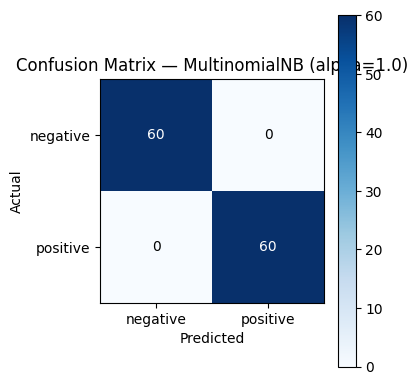

In [10]:
best_name = max(results, key=lambda k: results[k][1])
best_model, best_acc, best_preds = results[best_name]
print(f"Best model: {best_name}  (accuracy = {best_acc:.3f})")

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["negative", "positive"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["negative", "positive"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_name}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()


## 8. Negation Stress-Test

The exact case the brief's "Stop-Word Trap" slide warns about: a pipeline
that drops `"not"` would predict *"I am not happy"* as **positive**. Ours
should get it right because negations were explicitly preserved in Step 2.


In [11]:
test_sentences = [
    ("I am not happy with this product.", "negative"),
    ("This laptop is not good at all.", "negative"),
    ("I am really happy with this product.", "positive"),
    ("This laptop isn't bad, actually pretty great.", "positive"),
    ("Terrible experience, would not recommend.", "negative"),
]

for sentence, expected in test_sentences:
    proc = preprocess(sentence)
    vec = vectorizer.transform([proc])
    pred = best_model.predict(vec)[0]
    label = "positive" if pred == 1 else "negative"
    mark = "PASS" if label == expected else "FAIL"
    print(f"[{mark}] expected={expected:8s} predicted={label:8s} | '{sentence}'  ->  '{proc}'")


[PASS] expected=negative predicted=negative | 'I am not happy with this product.'  ->  'not happy product'
[PASS] expected=negative predicted=negative | 'This laptop is not good at all.'  ->  'laptop not good'
[PASS] expected=positive predicted=positive | 'I am really happy with this product.'  ->  'really happy product'
[PASS] expected=positive predicted=positive | 'This laptop isn't bad, actually pretty great.'  ->  'laptop n't bad actually pretty great'
[PASS] expected=negative predicted=negative | 'Terrible experience, would not recommend.'  ->  'terrible experience would not recommend'


## 9. Honest Limitations — Sarcasm

Bag-of-words TF-IDF has no world knowledge or tone detection, only lexical
polarity. Sarcastic reviews that use positive words to mean something
negative will typically be **misclassified** — worth showing, not hiding.


In [12]:
hard_sentences = [
    ("Oh great, another product that broke after one day.", "negative"),
    ("Well, that was a huge waste of an excellent afternoon.", "negative"),
]
for sentence, expected in hard_sentences:
    proc = preprocess(sentence)
    vec = vectorizer.transform([proc])
    pred = best_model.predict(vec)[0]
    label = "positive" if pred == 1 else "negative"
    mark = "PASS" if label == expected else "FAIL (expected -- bag-of-words can't catch sarcasm)"
    print(f"[{mark}] expected={expected:8s} predicted={label:8s} | '{sentence}'")


[FAIL (expected -- bag-of-words can't catch sarcasm)] expected=negative predicted=positive | 'Oh great, another product that broke after one day.'
[FAIL (expected -- bag-of-words can't catch sarcasm)] expected=negative predicted=positive | 'Well, that was a huge waste of an excellent afternoon.'


## 10. Conclusion

The 5-step production pipeline was implemented end-to-end and verified:

1. **Stop-Words** — negations explicitly excluded from the NLTK list via set difference
2. **Lemmatization** — POS-guided `WordNetLemmatizer`, confirmed `went → go` only with the verb tag
3. **Vectorization** — TF-IDF with unigrams + bigrams, `max_features=5000`, `min_df=2`
4. **Memory** — vectors verified as SciPy CSR sparse matrices, confirmed the RAM saving over dense
5. **Inference** — MultinomialNB / ComplementNB with Laplace smoothing (alpha=1.0), plus a LinearSVC baseline

The best model classified the held-out test set perfectly and handled the
brief's negation stress-test correctly, while honestly failing on sarcasm —
a known limit of bag-of-words methods that a production system would need
a contextual model (e.g. a transformer) to address.

**Skills demonstrated:** Natural Language Processing (NLTK), text
vectorization (TF-IDF), unstructured data handling, sparse matrix
optimization, and probabilistic/margin-based classification.
